# **1. Decision Tree Classifier**

## **1-1. Load Dataset & Analysis (iris)**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=113)

## **1-2. Decision Tree Classifier**

docs: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

> **모델 학습 및 예측**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train, y_train)
y_pred = dt_clf.predict(X_test)

> **classification report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
import pandas as pd

df = pd.DataFrame(iris_data.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
df['species'] = iris_data.target

df

## **1-3. Visualize Tree**

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(12,12))
tree.plot_tree(dt_clf)
plt.show()

## **1-4. Visualize Feature Importance**

In [ ]:
dt_clf.feature_importances_

In [ ]:
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
  print(name, value)

In [ ]:
import seaborn as sns
import numpy as np

# feature importance 추출
print("Feature Importances:\n{0}\n".format(np.round(dt_clf.feature_importances_, 3)))

# feature 별 feature importance 매핑
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
    print('{0}: {1:.3f}'.format(name, value))

# feature importance 시각화
sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)
plt.show()

## **1-5. Visualize Classification Result**

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, 2:]  # we only take the last two features.
y = iris.target

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

plt.figure(2, figsize=(8, 6))
plt.clf()

# Plot the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set2, edgecolor="k")
plt.xlabel("Petal length")
plt.ylabel("Petal width")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.show()

## **1-6. Difference Between max_depth**
* 여러 파라미터를 실험하기 위하여 파라미터를 변경하며 성능 실험 진행

In [ ]:
accuracy_scores = []
from sklearn import tree
plt.figure(figsize=(32, 10))

from sklearn.metrics import accuracy_score
for i in range(1, 5):
    dt_clf = DecisionTreeClassifier(max_depth = i, random_state=10)
    dt_clf.fit(X_train, y_train)
    plt.subplot(1, 4, i)
    tree.plot_tree(dt_clf)
    plt.title(f'Depths of {i}', fontsize=20)
    y_pred = dt_clf.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(6, 6))
plt.plot([f"Depths:{i}" for i in range(1,5)], accuracy_scores, marker='o')
plt.title("Accuracy difference between max depth parameters")
plt.show()

# **2. Random Forest Classifier**
> A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

> 디시전 트리 여러개를 통해 데이터셋을 서브 샘플링하고 앙상블링 하는 기법 (앙상블: 여러개의 classifier를 조합하여 성능을 올리는 기법)

* criterion = {“gini”, “entropy”}
* max_depth = maximun depth
* n_estimators: the number of trees in the forests

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

> **Feature importance based on mean decrease in impurity**


자료 출처: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html


In [ ]:
import numpy as np

# Random Forest Classifier로부터 중요 피쳐 추출
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
# np.std: standard deviation (표준편차)

In [ ]:
std

In [ ]:
forest_importances = pd.Series(importances, index=iris_data.feature_names)
forest_importances

> **What is MDI (Mean Decrease in Impurity)**
* Gini Importance Score와 동일한 뜻으로, 전체적으로 Classification의 불순도를 얼마나 감소 시키는지를 의미한다.

In [ ]:
import pandas as pd

forest_importances = pd.Series(importances, index=iris_data.feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
# 위의 결과와 비슷한 결과를 도출할 수 있음.

# **3. XGBoost Classifier**

> **Boosting**: 앙상블 기법 중 하나로, 정확도가 높지 않은 약한 모델들을 연속적으로 이어붙여 결과를 점진적으로 개선하는 방법

> **XGBoost**: 오류 데이터에 경사 하강법을 사용해 가중치를 부여하면서 오류를 개선하는 모델, 느리고 overfitting의 위험성이 있는 gradiant boosting의 단점 보완

> XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible and portable. It implements machine learning algorithms under the Gradient Boosting framework.

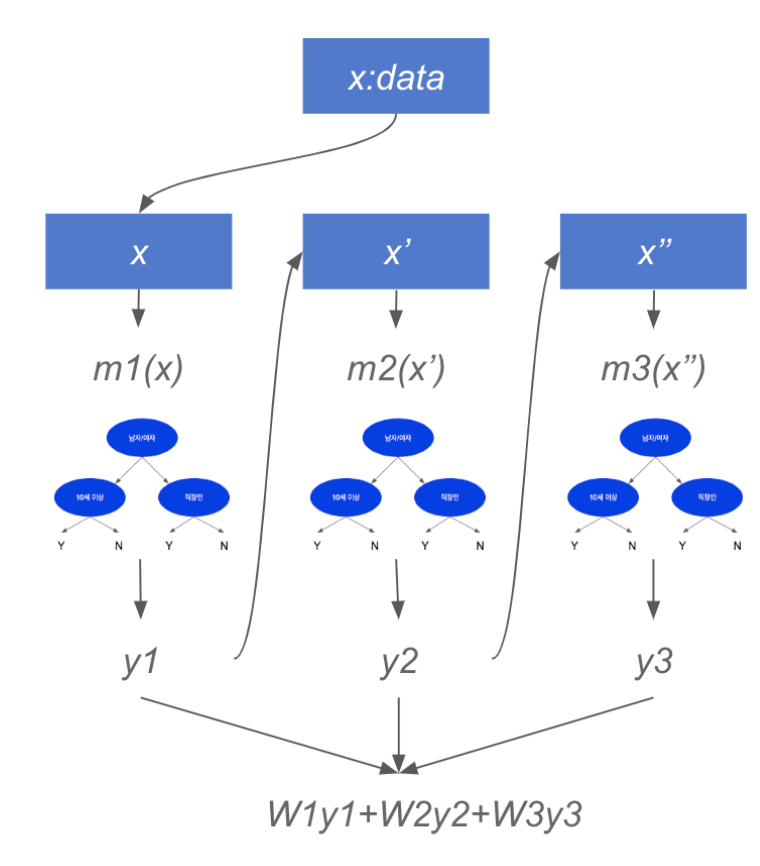


**XGB 참고 사이트**
- https://xgboost.readthedocs.io/en/stable/python/index.html
- https://zephyrus1111.tistory.com/232


In [ ]:
## sklearn에서는 xgboost를 제공하지 않으므로 직접 설치

!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# **4. 실습과제**

* sklearn의 breast cancer dataset으로 XGBoost Classifier를 학습시키고, classification report를 출력하세요. 이때, 아래 사이트의 parameter를 참고해서 2가지 이상의 parameter를 튜닝 하세요. (ex. learning_rate, max_depth, n_estimators, ect...)
- reference: https://xgboost.readthedocs.io/en/latest/parameter.html

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=113)

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Your code here